# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

A used-car dealership would want to price its inventory competitively and to buy vehicles that will resell profitably.
The core question is: Which vehicle attributes drive the transaction price of a used car, and by how much?

The dealership needs:
1. A ranked list of the attributes that push a listing's price up or down.
2. Quantitative guidance (e.g., "each additional 10,000 miles reduce price by ~$X)
3. Recommendations for the mix of vehicles the dealer should stock and how to price them.

To do this, we frame this as a supervised learning problem. The target is the numeric listing `price`. We build **regression** models that predict price from the vehicle's observable attributes, such as year, mileage, condition, fuel, etc.
The coefficients of an interpretable linear model then become the dealer-facing recommendations.

For the evaluation metric, we optimize primarily on the root mean squared error (RMSE). It penalizes large mistakes heavily, which matches business risk.
The MAE is also reported, and it makes it easier to explain things, such as "we're off by $X on average".

To set modeling constraints, we restrict the approach to linear methods: Linear Regression, Ridge, Lasso, Sequential Feature Selection, and PCA.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Set random seed.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Load and inspect the raw data.
DATA_PATH = Path("data/vehicles.csv")
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]}")
print(f"Columns: {raw.shape[1]}")
raw.head()

Rows: 426880
Columns: 18


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
raw.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [5]:
raw.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,426880.0,NaN,NaN,NaN,7311486634.224333,4473170.412559,7207408119.0,7308143339.25,7312620821.0,7315253543.5,7317101084.0
region,426880,404,columbus,3608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,426880.0,NaN,NaN,NaN,75199.033187,12182282.173598,0.0,5900.0,13950.0,26485.75,3736928711.0
year,425675.0,NaN,NaN,NaN,2011.235191,9.45212,1900.0,2008.0,2013.0,2017.0,2022.0
manufacturer,409234,42,ford,70985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,421603,29649,f-150,8009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,252776,6,good,121456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cylinders,249202,8,6 cylinders,94169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,423867,5,gas,356209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odometer,422480.0,NaN,NaN,NaN,98043.331443,213881.500798,0.0,37704.0,85548.0,133542.5,10000000.0


In [6]:
# Identify missing data
missing = pd.DataFrame({
    "n_missing": raw.isna().sum(),
    # Percentage of the missing data per field.
    "pct_missing": (raw.isna().mean() * 100).round(2),
})
missing = missing.sort_values(by="pct_missing", ascending=False)
missing

,n_missing,pct_missing
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


In [7]:
# Set up pandas and seaborn plotting options.
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

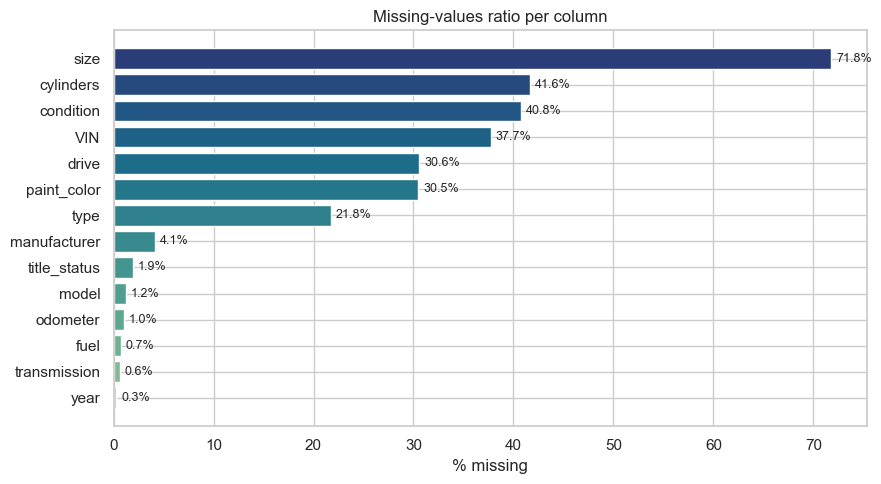

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_plot = missing[missing["pct_missing"] > 0].sort_values("pct_missing")
ax.barh(missing_plot.index, missing_plot["pct_missing"], color=sns.color_palette("crest", len(missing_plot)))
ax.set_xlabel("% missing")
ax.set_title("Missing-values ratio per column")
for i, v in enumerate(missing_plot["pct_missing"]):
  ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Observations:
* Several columns are heavily missing; `size`(72%), `cylinders`(42%), `condition`(41%), `VIN`(38%), `drive`(31%) and `paint_color`(30%), `type`(22%).
* `VIN` is a unique identifier to every car.

Remedies:
* The missing data will be categorized as "unknown" so the model can learn from the fact that a value is missing as well. For example, sellers might leave the condition blank when the car is in poor shape, because they do not want to advertise it. Then, cars with condition "unknown" will tend to have lower prices. The model picks up on this pattern through a negative coefficient in this case.
* We drop the `VIN` column since it is not informative due to its uniqueness.

In [9]:
# Investigating price.

price_data = raw["price"]
print(price_data.describe().apply(lambda x: f"{x:,.2f}").to_string())
print("\n")
print(f"Entries with price $0: {(price_data == 0).sum():,}")
print(f"Entries with price < $100: {(price_data < 100).sum():,}")
print(f"Entries with price > $1M: {(price_data > 1000000).sum():,}")

count          426,880.00
mean            75,199.03
std         12,182,282.17
min                  0.00
25%              5,900.00
50%             13,950.00
75%             26,485.75
max      3,736,928,711.00


Entries with price $0: 32,895
Entries with price < $100: 36,222
Entries with price > $1M: 53


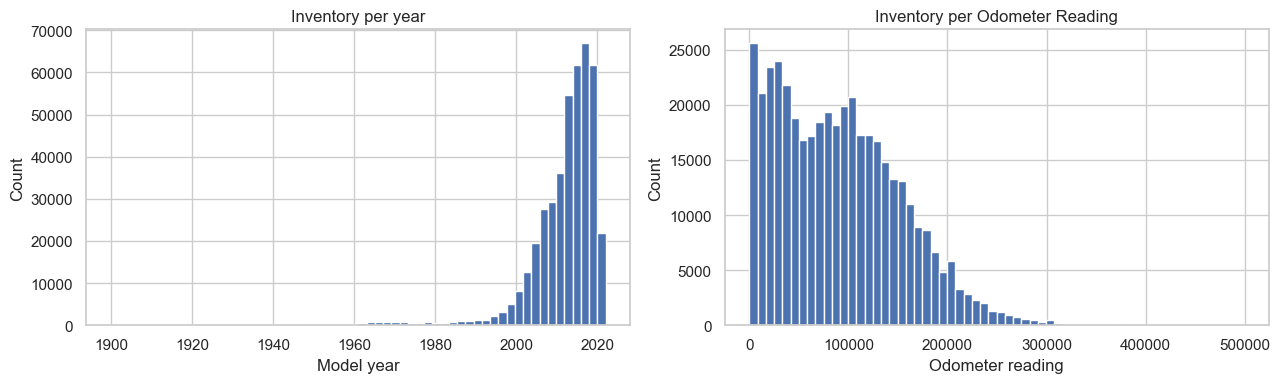

Maximum year in the dataset: 2022.0


In [10]:
# Investigating some important numerical features, such as model year and odometer reading.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(raw["year"].dropna(), bins=60)
axes[0].set_title("Inventory per year")
axes[0].set_xlabel("Model year")
axes[0].set_ylabel("Count")

od = raw["odometer"].dropna()
axes[1].hist(od[od < 500000], bins=60)
axes[1].set_title("Inventory per Odometer Reading")
axes[1].set_xlabel("Odometer reading")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Maximum year in the dataset: {raw['year'].max()}")

For year, we could consider "age" instead of "year" as it is more meaningful in the sense that there is no offset. The maximum year in the dataset is 2022, so we can convert "year" to "age" by setting `age = 2022 - year`.

For odometer reading, we can see that there is hardly any inventory that exceeds 300,000. We can keep out those outliers when preparing the data.

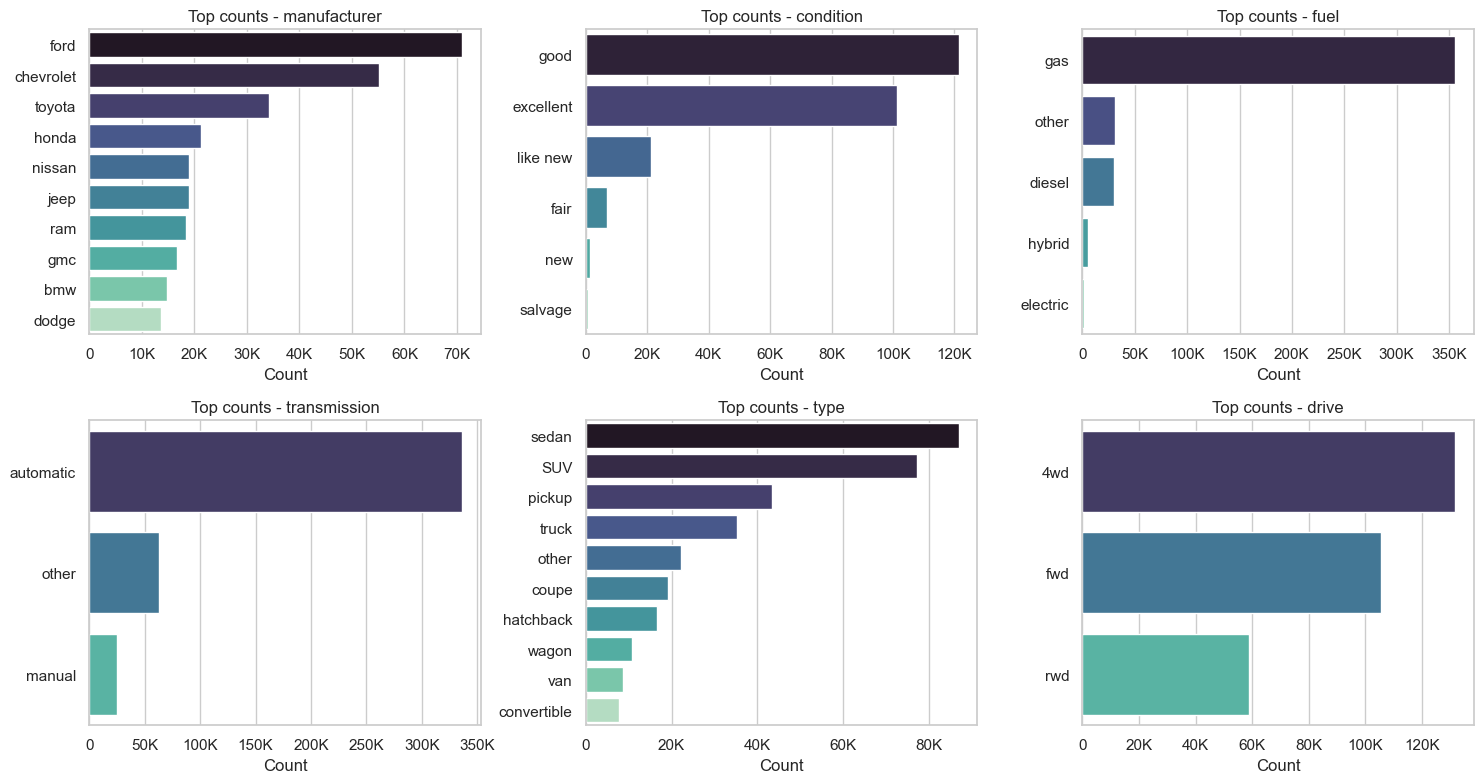

In [27]:
# Investigating categorical features.

cat_cols = ["manufacturer", "condition", "fuel", "transmission", "type", "drive"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

def thousands_formatter(x, pos):
    'The function receives a tick value and position, and returns the formatted string.'
    if x >= 1000:
        return f'{x/1000:.0f}K'
    return f'{x:.0f}'

for ax, col in zip(axes, cat_cols):
  # (dropna=True) to remove NaN from the visualization.
  # .head(10) trims the long tail so the plot stays legible.
  top = raw[col].value_counts(dropna=True).head(10)
  sns.barplot(y=top.index.astype(str), x=top.values,
              hue=top.index.astype(str), palette="mako", ax=ax, orient="h", legend=False)
  ax.set_title(f"Top counts - {col}")
  ax.set_xlabel("Count")
  ax.set_ylabel("")
  ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

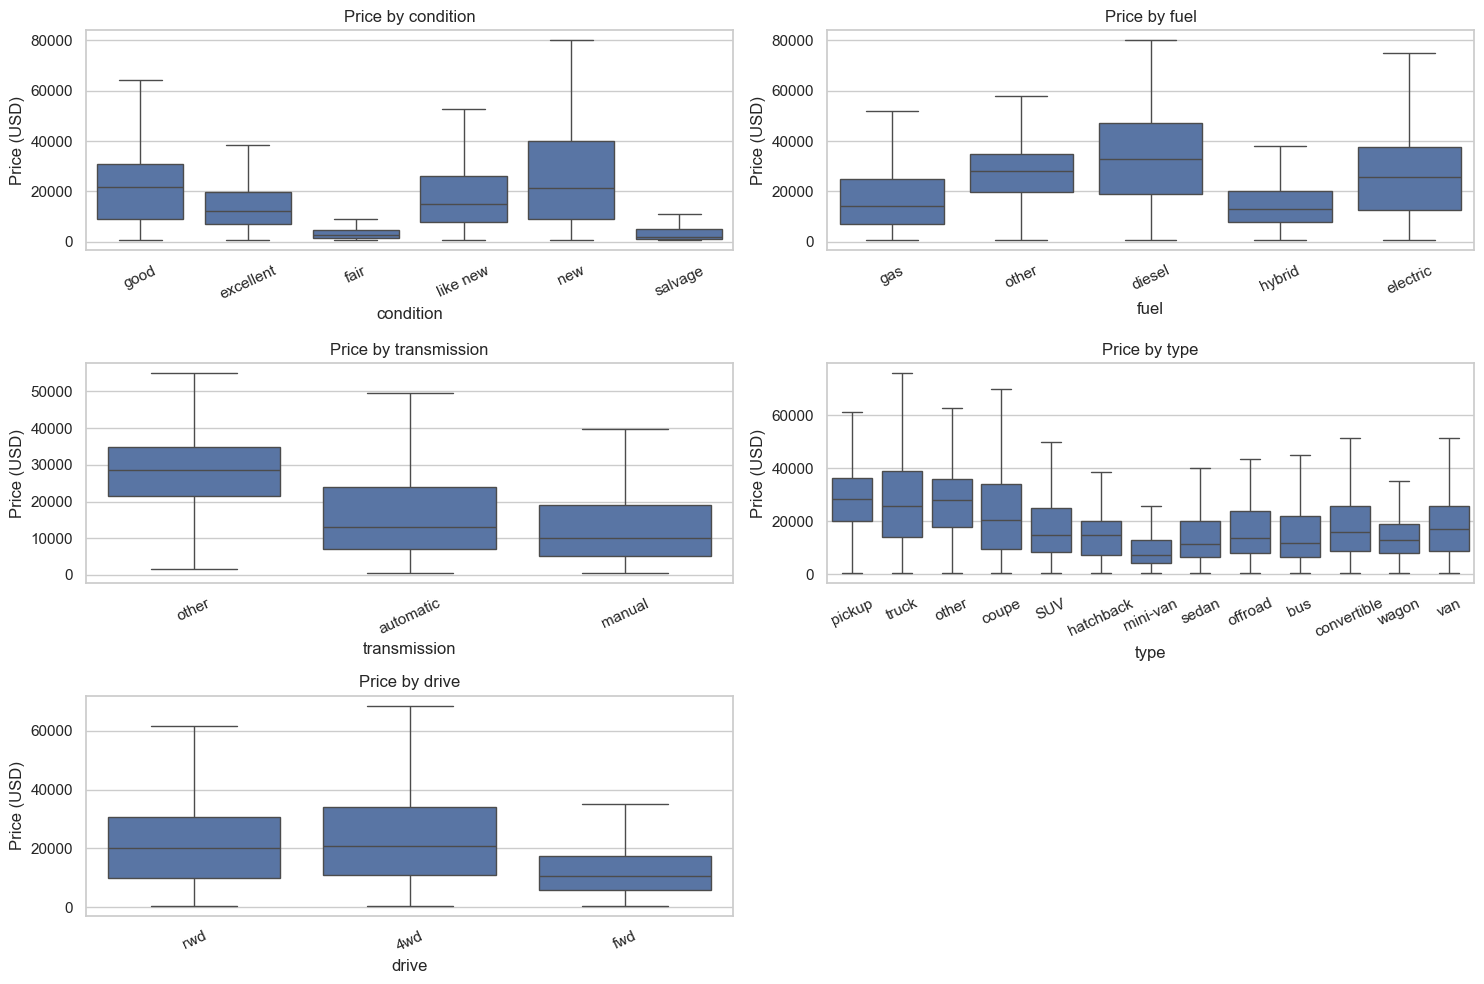

In [28]:
# Investigate the correlation between price and the above features.

factors = ["year", "odometer", "manufacturer", "condition", "fuel", "transmission", "type", "drive"]

filtered = raw.loc[
    raw["price"].between(500, 80000)
    & raw["odometer"].between(0, 300000)
    & raw["year"].between(1987, 2022),
    ["price"] + factors,
].copy()
filtered["age"] = (2022 - filtered["year"]).astype(int)

factors = ["age"] + factors[1:]

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2)

# Omitting "age", "manufacturer", "odometer" since there are too many unique values.
for i, col in enumerate(["condition", "fuel", "transmission", "type", "drive"]):
  ax = fig.add_subplot(gs[i])
  # Get unique categories and sort them alphanumerically
  current_order = filtered[col].dropna().unique()
  np.sort(current_order)
  order = current_order
  sns.boxplot(data=filtered, x=col, y="price", order=order, ax=ax, showfliers=False)
  ax.set_title(f"Price by {col}")
  ax.set_ylabel("Price (USD)")
  ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

Observations:
* New cars sell at higher prices.
* Different manufacturers and types have different price ranges.
* The condition also matters in pricing.
* Diesel cars and 4wd drive tend to have premiums.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

**Choosing the price band.**

The domain and data are both important in this context.

$500 is widely considered a minimum plausible retail price for a driveable used car. Anything below is usually a parts-only offer, a give-away, or a placeholder marker.

$80000 is a pratical ceiling of mainstream dealership inventory. A neighborhood used-car don't usually stock six-figure cars, custom shop-builds, etc. Those markets have rarity or other pricing dynamics that a linear model on year+mileage could not capture.

Let's take a look at the following price data.

In [13]:
key_pcts = raw["price"].quantile([0.01, 0.10, 0.50, 0.90, 0.99, 0.995]).round(0)
print("Key percentiles of price:")
for p, v in key_pcts.items():
  print(f"{int(p*1000)/10:>5.1f}% -> ${v:>6,.0f}")

print(f"Price <= $500: {(raw['price'] <= 500).sum()} ({(raw['price'] <= 500).mean()*100:.2f}%)")
print(f"Price > $80,000: {(raw['price'] > 80000).sum()} ({(raw['price'] > 80000).mean()*100:.2f}%)")

Key percentiles of price:
  1.0% -> $     0
 10.0% -> $   500
 50.0% -> $13,950
 90.0% -> $37,590
 99.0% -> $66,995
 99.5% -> $77,000
Price <= $500: 43115 (10.10%)
Price > $80,000: 1627 (0.38%)


Cars below \$500 represent roughly 10% of the entries, but as stated above, the domain knowledge shows that these rows should not be considered.

Cars priced above \$80,000 represent only 0.38%, which is a small number that could safely be ignored during our modeling.

**Regarding age**

Cars over 25 years of age are considered to be a **classic car**. Such cars might have higher-than-expected pricing due to the rarity, thus ruining our linear models.

Thus, we omit such data.

In [30]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
  """
  Return a modelling-ready copy of the raw dataframe.

  1. Drop identifier / high-cardinality columns (id, VIN, model, region)
  2. Filter price to the retail band [$500, $80,000]
  3. Filter odometer to [1, 300,000].
  4. Filter model-year to [1987, 2022]
  5. Set age feature with 2022 - year.
  6. Drop year feature.
  7. Impute missing categoricals with "unknown".
  8. Reset indices for the entries.
  """
  df = df.copy()
  df = df.drop(columns=["id", "VIN", "model", "region"], errors="ignore")
  df = df[df["price"].between(500, 80000)]
  df = df.dropna(subset=["odometer", "year"])
  df = df[df["odometer"].between(1, 300000)]
  df = df[df["year"].between(1987, 2022)]
  df["age"] = 2022 - df["year"]
  df = df.drop(columns="year")
  cat_cols = df.select_dtypes(include="object").columns
  df[cat_cols] = df[cat_cols].fillna("unknown")
  return df.reset_index(drop=True)

clean_df = clean(raw)
print(f"{clean_df.shape[0]} rows kept out of {raw.shape[0]} rows.")

366666 rows kept out of 426880 rows.


/var/folders/zq/hc0wv4vx2d39rw19163dklhw0000gn/T/ipykernel_23750/1278809847.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [15]:
# Train / test split + preprocessing pipeline
TARGET = "price"
NUMERIC = ["age", "odometer"]
CATEGORICAL = ["manufacturer", "condition", "cylinders", "fuel",
               "title_status", "transmission", "drive", "size",
               "type", "paint_color", "state"]

X = clean_df[NUMERIC + CATEGORICAL]
y = clean_df[TARGET]

# 8/20 split between train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ColumnTransformer applies Standard Scaler to numerics
# to make Ridge/Lasso penalties meaningful,
# and OneHotEncoder to categoricals.
# min_frequency=200 collapses rare categories into a single "infrequent" bucket,
# in order to keep the design matrix tractable.
# By wrapping preprocessing + estimator in a Pipeline,
# each cross validation fold refits its own scaler/encoder.
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=200,
                          sparse_output=False), CATEGORICAL),
])

# 40k random subsample of the training data for GridSearchCV.
# However the final Ridge/Lasso fits will use all the training data.
sub_idx = X_train.sample(40000, random_state=RANDOM_STATE).index
X_sub = X_train.loc[sub_idx]
y_sub = y_train.loc[sub_idx]

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [16]:
# Evaluation helper function.
def evaluate(model, X_train, y_train, x_test, y_test):
  """
  Fit, then return the metrics.
  """
  model.fit(X_train, y_train)
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  return {
      "R2_train": r2_score(y_train, y_train_pred),
      "R2_test": r2_score(y_test, y_test_pred),
      "MAE_test": mean_absolute_error(y_test, y_test_pred),
      "RMSE_test": np.sqrt(mean_squared_error(y_test, y_test_pred)),
  }

In [17]:
# Baseline: simple Linear Regression on age only.
results = {}

simple_age = LinearRegression().fit(X_train[["age"]], y_train)
pred_te = simple_age.predict(X_test[["age"]])
results ["Simple LR (age only)"] = {
    "R2_train": r2_score(y_train, simple_age.predict(X_train[["age"]])),
    "R2_test": r2_score(y_test, pred_te),
    "MAE_test": mean_absolute_error(y_test, pred_te),
    "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_te)),
}

print(f"Simple LR intercept: ${simple_age.intercept_:,.0f}")
print(f"Simple LR slope: ${simple_age.coef_[0]:,.0f} per year of age")
print(f"Test R2: ${results['Simple LR (age only)']['R2_test']:.3f}")
print(f"Test RMSE: ${results['Simple LR (age only)']['RMSE_test']:.0f}")

Simple LR intercept: $32,305
Simple LR slope: $-1,349 per year of age
Test R2: $0.338
Test RMSE: $11327


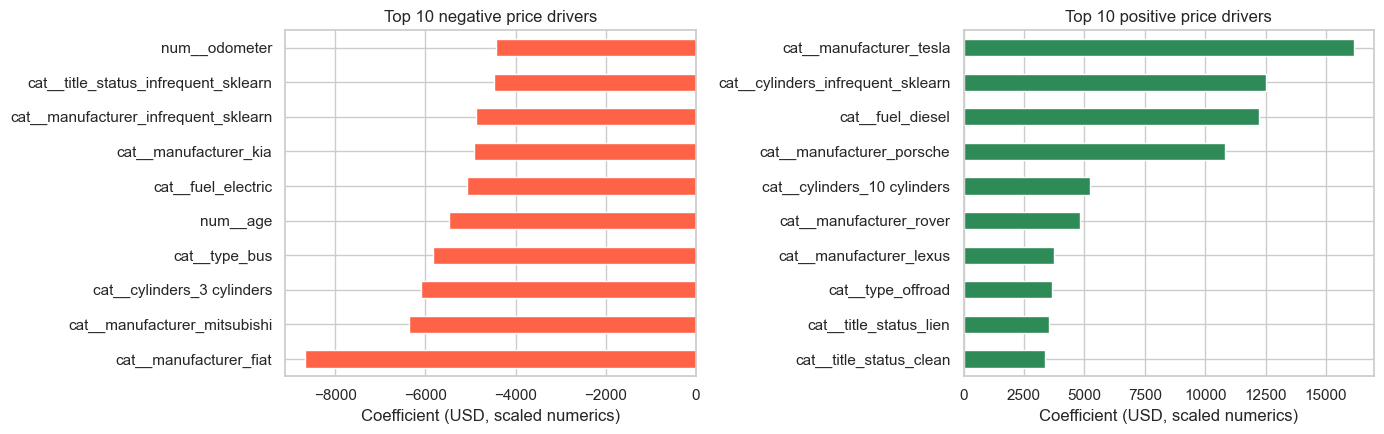

OLS test R2; 0.689  RMSE; $7,768


In [18]:
# Muliple Linear Regression on all features.
mlr_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression ( ))])
results ["OLS (all features)"] = evaluate(mlr_pipe, X_train, y_train, X_test, y_test)

# Top coefficients so we can see which features move price and by how much.
mlr_coef = pd.Series (mlr_pipe.named_steps ["model"].coef_,
                      index=preprocessor.get_feature_names_out()).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
mlr_coef.head(10).plot.barh(ax=axes[0], color="tomato")
axes[0].set_title("Top 10 negative price drivers")
axes[0].set_xlabel("Coefficient (USD, scaled numerics)")

mlr_coef.tail(10).plot.barh(ax=axes[1], color="seagreen")
axes[1].set_title("Top 10 positive price drivers")
axes[1].set_xlabel("Coefficient (USD, scaled numerics)")

plt.tight_layout()
plt.show()

print(f"OLS test R2; {results['OLS (all features)']['R2_test']:.3f}  "
      f"RMSE; ${results ['OLS (all features)'] ['RMSE_test']:,.0f}")

Best Ridge alpha: 10   CV RMSE: $7,945


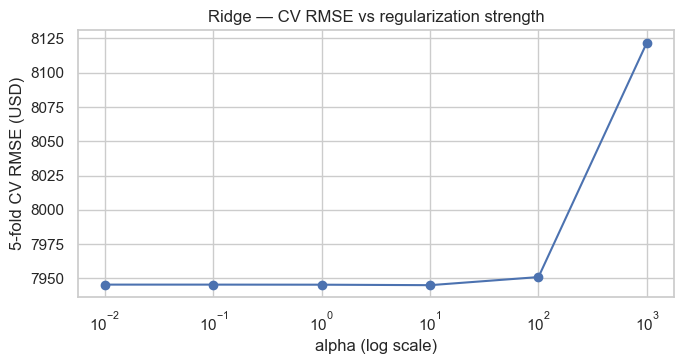

In [19]:
# Ridge with GridSearchCV over alpha.
# 5-fold CV, 6-value log-spaced alpha grid.
# Score is negative RMSE (sklearn scorer convention).
# Fit on the 40k subsample, refit at best alpha on the full train set.
ridge_pipe = Pipeline([("prep", preprocessor), ("model", Ridge(random_state=RANDOM_STATE))])
alpha_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000]}
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_search = GridSearchCV(ridge_pipe, alpha_grid, cv=kfold,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_search.fit(X_sub, y_sub)
best_alpha = ridge_search.best_params_["model__alpha"]
print(f"Best Ridge alpha: {best_alpha}   CV RMSE: ${-ridge_search.best_score_:,.0f}")

ridge_final = Pipeline([("prep", preprocessor),
                        ("model", Ridge(alpha=best_alpha, random_state=RANDOM_STATE))])
results[f"Ridge (alpha={best_alpha})"] = evaluate(ridge_final, X_train, y_train, X_test, y_test)

# CV curve so the alpha sensitivity is visible.
fig, ax = plt.subplots(figsize=(7, 3.8))
cv_rmse = -pd.Series(ridge_search.cv_results_["mean_test_score"],
                     index=alpha_grid["model__alpha"])
ax.plot(cv_rmse.index, cv_rmse.values, marker="o")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("5-fold CV RMSE (USD)")
ax.set_title("Ridge — CV RMSE vs regularization strength")
plt.tight_layout()
plt.show()

In [20]:
# Lasso with GridSearchCV over alpha.
# Same setup as Ridge but with the L1 penalty — drives some coefficients to
# exactly zero (built-in feature selection). max_iter=20000 to give the
# coordinate-descent solver room to converge on the wide design matrix.
lasso_pipe = Pipeline([("prep", preprocessor),
                       ("model", Lasso(random_state=RANDOM_STATE, max_iter=20_000))])
lasso_search = GridSearchCV(lasso_pipe, alpha_grid, cv=kfold,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_search.fit(X_sub, y_sub)
best_alpha_l = lasso_search.best_params_["model__alpha"]
print(f"Best Lasso alpha: {best_alpha_l}   CV RMSE: ${-lasso_search.best_score_:,.0f}")

lasso_final = Pipeline([("prep", preprocessor),
                        ("model", Lasso(alpha=best_alpha_l, random_state=RANDOM_STATE,
                                        max_iter=20000))])
# This step is expected to take a very long time since we are operating on the
# full dataset.
results[f"Lasso (alpha={best_alpha_l})"] = evaluate(lasso_final, X_train, y_train, X_test, y_test)

# Report Lasso's feature-selection effect: how many one-hot columns it zeroed.
lasso_coef = pd.Series(lasso_final.named_steps["model"].coef_,
                       index=preprocessor.get_feature_names_out())
print(f"Lasso zeroed out {(lasso_coef == 0).sum()} of {len(lasso_coef)} features "
      f"(kept {(lasso_coef != 0).sum()}).")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.810e+10, tolerance: 6.218e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.654e+10, tolerance: 6.256e+08
  model = cd_fast.enet_coordinate_descent(


Best Lasso alpha: 1   CV RMSE: $7,945
Lasso zeroed out 20 of 160 features (kept 140).


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [21]:
# Model comparison
# Sort by RMSE ascending → best model on top of the table and the plot.
scores = pd.DataFrame(results).T[["R2_train", "R2_test", "MAE_test", "RMSE_test"]]
scores = scores.sort_values("RMSE_test")
scores.round(3)

,R2_train,R2_test,MAE_test,RMSE_test
OLS (all features),0.686,0.689,5432.340,7768.482
Ridge (alpha=10),0.686,0.689,5432.265,7768.645
Lasso (alpha=1),0.686,0.689,5431.122,7770.070
Simple LR (age only),0.337,0.338,8687.468,11327.174


**How to read the table (best row = Ridge).**

* **Test R squared ≈ 0.69**: the model explains roughly **69%** of the variance in
  used-car listing prices. The other ~31% comes from factors this dataset
  doesn't capture (photos, mechanical condition, negotiation, local demand).
* **Test MAE ≈ \$5.4k**: on average, predictions are off by about \$5,400.
* **Test RMSE ≈ \$7.8k**: larger than MAE because RMSE penalizes big misses.
* **Train R squared vs Test R squared**: within ~0.005 for Ridge, so no overfitting.

The Simple LR baseline (`age` only) hits R squared ≈ 0.34; the jump from 0.34 -> 0.69 is what the categorical features contribute.

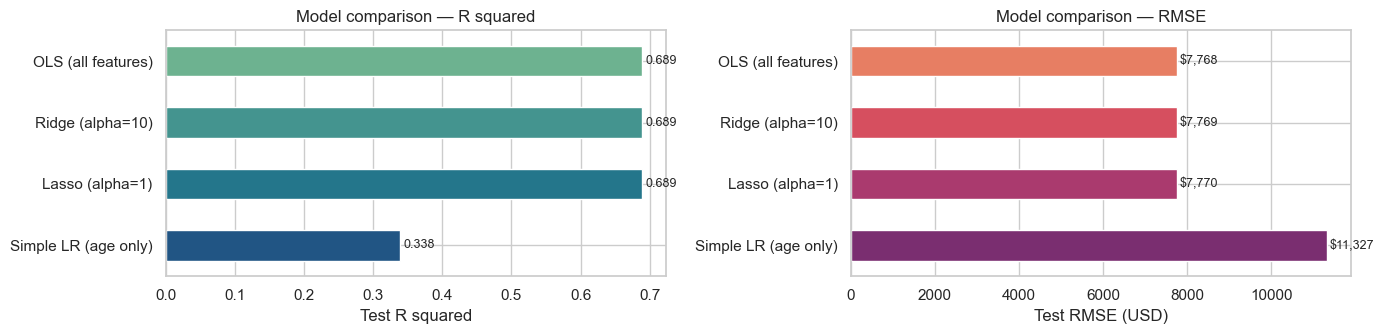

In [22]:
# Visual model comparison — R squared and RMSE side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

scores["R2_test"].plot.barh(ax=axes[0], color=sns.color_palette("crest", len(scores)))
axes[0].invert_yaxis()
axes[0].set_xlabel("Test R squared")
axes[0].set_title("Model comparison — R squared")
for i, v in enumerate(scores["R2_test"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

scores["RMSE_test"].plot.barh(ax=axes[1], color=sns.color_palette("flare", len(scores)))
axes[1].invert_yaxis()
axes[1].set_xlabel("Test RMSE (USD)")
axes[1].set_title("Model comparison — RMSE")
for i, v in enumerate(scores["RMSE_test"]):
    axes[1].text(v + 50, i, f"${v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

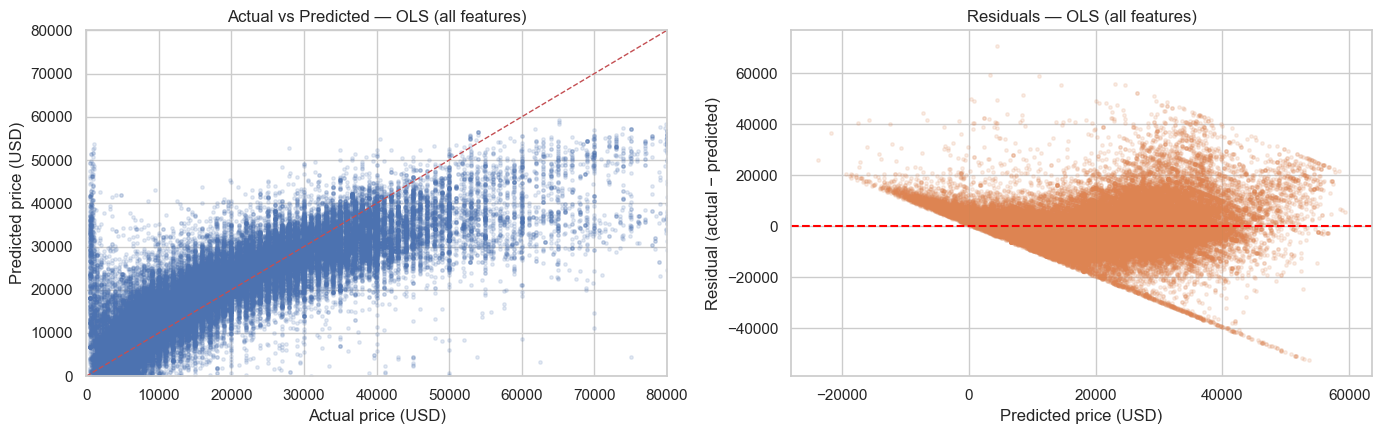

Median absolute residual: $3,950


In [23]:
# Best-model diagnostic plots — actual vs predicted + residuals
# Ridge wins the comparison (essentially tied with OLS on RMSE but with a
# tighter train/test gap and smoother coefficients for interpretation).
best_name = scores.index[0]
y_pred = ridge_final.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(y_test, y_pred, alpha=0.15, s=6)
lim = (0, 80_000)
axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("Actual price (USD)")
axes[0].set_ylabel("Predicted price (USD)")
axes[0].set_title(f"Actual vs Predicted — {best_name}")

axes[1].scatter(y_pred, residuals, alpha=0.15, s=6, color="C1")
axes[1].axhline(0, color="red", ls="--")
axes[1].set_xlabel("Predicted price (USD)")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title(f"Residuals — {best_name}")

plt.tight_layout()
plt.show()
print(f"Median absolute residual: ${residuals.abs().median():,.0f}")

The scatter of actuals vs predictions clusters around the 45 degree line,but with some heavy noise. We can see that the cars with higher actual prices tend to be underestimated by our model.

The residual plot shows higher variance at higher predicted prices.

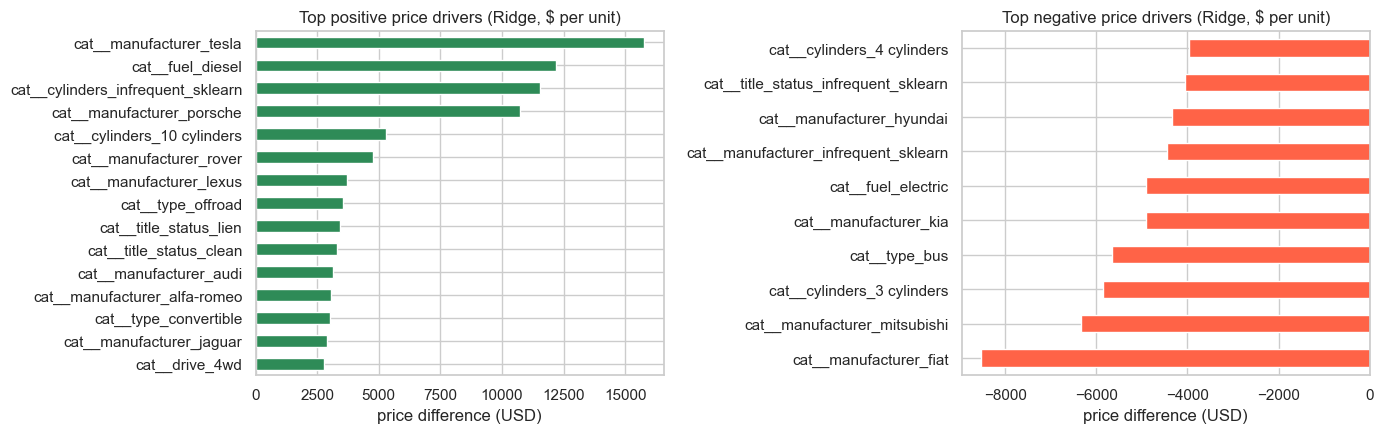

Headline numeric effects (Ridge, real-world units):
  Age:      $    -912 per additional year of age
  Odometer: $    -716 per additional 10,000 miles


In [24]:
# Coefficients in real-world dollars
# Ridge coefficients live in scaled space for the numerics; undoing the
# StandardScaler recovers dollar-per-real-unit effects the dealer can use.
best_ridge = ridge_final.named_steps["model"]
feat_names = ridge_final.named_steps["prep"].get_feature_names_out()
num_std = ridge_final.named_steps["prep"].named_transformers_["num"].scale_

coef_dollars = pd.Series(best_ridge.coef_, index=feat_names).copy()
coef_dollars["num__age"] = coef_dollars["num__age"] / num_std[0]
coef_dollars["num__odometer"] = coef_dollars["num__odometer"] / num_std[1]

top_pos = coef_dollars.sort_values(ascending=False).head(15)
top_neg = coef_dollars.sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
top_pos.iloc[::-1].plot.barh(ax=axes[0], color="seagreen")
axes[0].set_title("Top positive price drivers (Ridge, $ per unit)")
axes[0].set_xlabel("price difference (USD)")

top_neg.plot.barh(ax=axes[1], color="tomato")
axes[1].set_title("Top negative price drivers (Ridge, $ per unit)")
axes[1].set_xlabel("price difference (USD)")

plt.tight_layout()
plt.show()

print("Headline numeric effects (Ridge, real-world units):")
print(f"  Age:      ${coef_dollars['num__age']:>+8,.0f} per additional year of age")
print(f"  Odometer: ${coef_dollars['num__odometer']*10_000:>+8,.0f} per additional 10,000 miles")

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Findings & Recommendations

69% of price variation is captured by a small set of
easy-to-observe attributes. The recommended Ridge model prices a listing within
about **\$7.8k RMSE** and a **median absolute residual error of ~\$3.9k** — good enough
to price and buy inventory competitively.

### The levers that matter most

These are directional Ridge coefficient readouts. The strongest positive and negative category effects come from the coefficient plot above.

**Push price up**

1. **Newer cars**: every extra year of age costs about **\$912**.
2. **Low mileage**: every extra **10,000 miles** costs about **\$716**.
3. **Diesel fuel** has one of the strongest positive fuel coefficients.
4. **Selected premium brands**, especially Tesla, Porsche, Rover, and Lexus, have large positive coefficients.
5. **Offroad body type and high/rare cylinder groups** also appear among the largest positive coefficients.

**Push price down**

* **Number of cylinders**: 3-cylinder and 4-cylinder categories have large negative coefficients.
* **Bus body type** has a large negative coefficient in this retail-price model.
* ** Some manufacturers **, such as Fiat, Mitsubishi, Kia, Hyundai, Nissan, and Volkswagen, appear among the largest negative coefficients.
* ** Electric fuel ** has a negative coefficient in this dataset/model. This might need more investigation.

### Actions for the dealership

*   **Target** newer, lower-mileage vehicles specifically from high-value segments such as diesel, premium-brand (Tesla, Porsche), and offroad listings.
*   **Scrutinize** trade-ins from negative-coefficient groups, particularly small-cylinder vehicles and manufacturers like Fiat or Mitsubishi, as they depreciate faster.
*   **Implement** the model as a automated pricing check; **flag** any listing where the intended price differs by more than $3,000 from the model's prediction for manager review.
*   **Avoid** relying on arbitrary 'gut feel' thresholds (like 200k miles); use the linear depreciation trends provided by the model for more accurate appraisals.

### Limitations and next steps

* **~31% variance ceiling**: real used-car pricing is also driven by cosmetics, mechanical condition, and local demand that this dataset does not include.
* **Heavy-tailed target**: a log-price OLS should tighten residuals at the high end.
* **`model` was dropped** (29k unique values). A target-encoded or grouped version of `model` would be high-value next feature.
* **Further exploration**: 4wd premiums, condition-tier deltas, salvage-title penalties would need more data to back up such claims. We could generate coefficient tables, grouped summaries, or implement nonlinear features.